<a href="https://colab.research.google.com/github/hachinmai25-dot/seasonal-agriculture-performance/blob/main/seasonal__agriculture_performance__analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


SEASONAL SAMPLE COUNTS
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

SEASONAL MEANS
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR  Revenue_INR  \
Season                                                                
Kharif             5.64              46.31   178914.65    710719.06   
Rabi               5.08              41.49    87689.47    601526.05   
Zaid               4.67              38.89   -24804.82    519171.90   

        Total_Cost_INR  Market_Price_INR_Tonne  Water_Used_m3  \
Season                                                          
Kharif       531804.41                44850.91        6102.20   
Rabi         513836.58                44747.97        5846.99   
Zaid         543976.73                44212.03        6419.89   

        Water_Efficiency_t_per_1000m3  Fertilizer_kg_ha  Pesticide_Litre_ha  \
Season                                                                        
Kharif                           5.89     

Calculating seasonal environmental correlations:   0%|          | 0/3 [00:00<?, ?it/s]


SEASON-SPECIFIC ENVIRONMENTAL CORRELATIONS
    Season   Environment_Variable  Yield_Tonnes_Ha  Profit_INR
0   Kharif            Rainfall_mm           -0.019      -0.101
1   Kharif      Avg_Temperature_C           -0.011      -0.020
2   Kharif           Humidity_pct           -0.017      -0.033
3   Kharif     Sunlight_Hours_Day           -0.021       0.024
4   Kharif                Soil_pH           -0.026      -0.039
5   Kharif      Soil_Moisture_pct            0.001       0.022
6   Kharif  Disease_Pest_Risk_pct           -0.027      -0.079
7     Rabi            Rainfall_mm            0.042       0.130
8     Rabi      Avg_Temperature_C            0.054       0.101
9     Rabi           Humidity_pct            0.018      -0.018
10    Rabi     Sunlight_Hours_Day            0.009      -0.011
11    Rabi                Soil_pH           -0.016       0.008
12    Rabi      Soil_Moisture_pct           -0.021      -0.006
13    Rabi  Disease_Pest_Risk_pct            0.015       0.067
14    Zaid 

Running seasonal statistical tests:   0%|          | 0/5 [00:00<?, ?it/s]


STATISTICAL TESTS FOR DIFFERENCES BETWEEN SEASONS
                          Metric  Kruskal_Wallis_H  p_value  \
0                Yield_Tonnes_Ha          68.60430  0.00000   
1                     Profit_INR         101.92605  0.00000   
2                  Water_Used_m3           5.96890  0.05057   
3  Water_Efficiency_t_per_1000m3          56.81148  0.00000   
4          Disease_Pest_Risk_pct        1430.91013  0.00000   

   Significant_at_5pct  
0                 True  
1                 True  
2                False  
3                 True  
4                 True  

STATES WITH THE LARGEST SEASONAL YIELD DIFFERENCES
State
Punjab            4.51
Maharashtra       3.22
Gujarat           2.24
Andhra Pradesh    2.21
Madhya Pradesh    2.20
Karnataka         2.01
Tamil Nadu        1.42
Telangana         1.29
dtype: float64

CROPS WITH THE LARGEST SEASONAL YIELD DIFFERENCES
Crop
Sugarcane    15.04
Rice          0.81
Maize         0.67
Chilli        0.55
Wheat         0.51
Groundnut   

Creating seasonal boxplots:   0%|          | 0/6 [00:00<?, ?it/s]

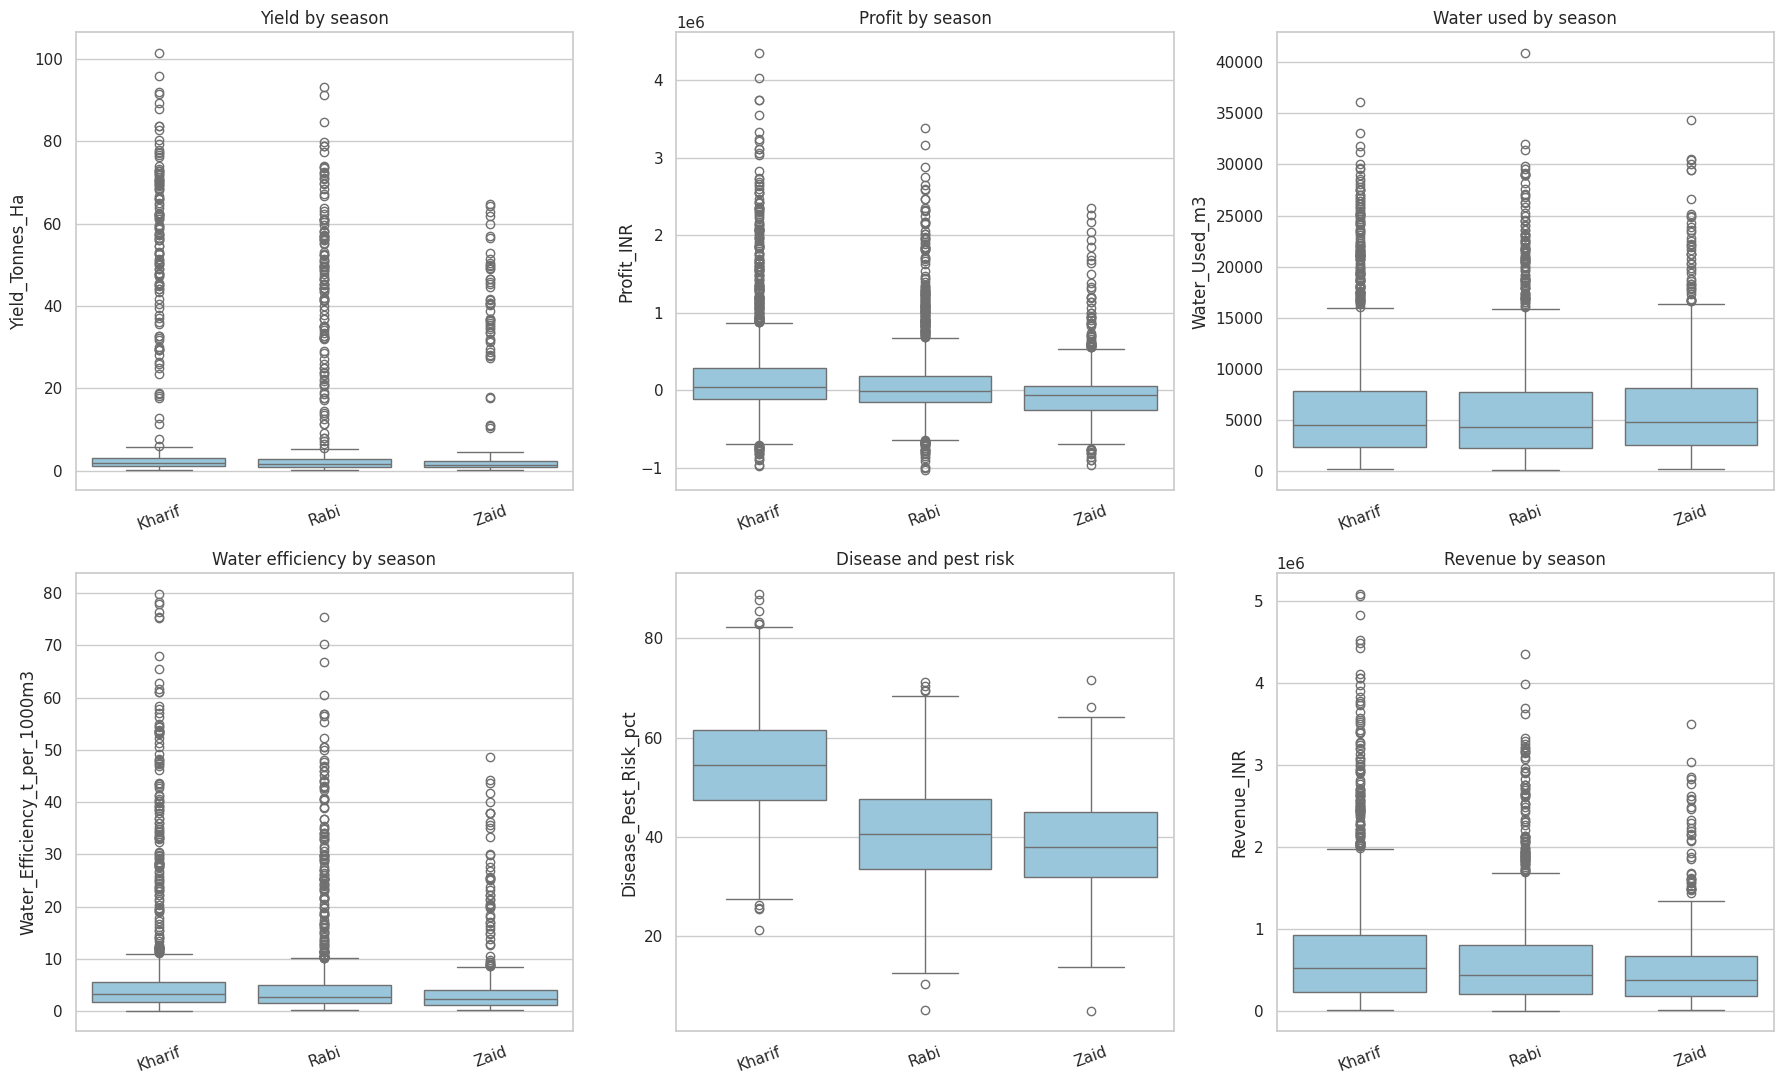

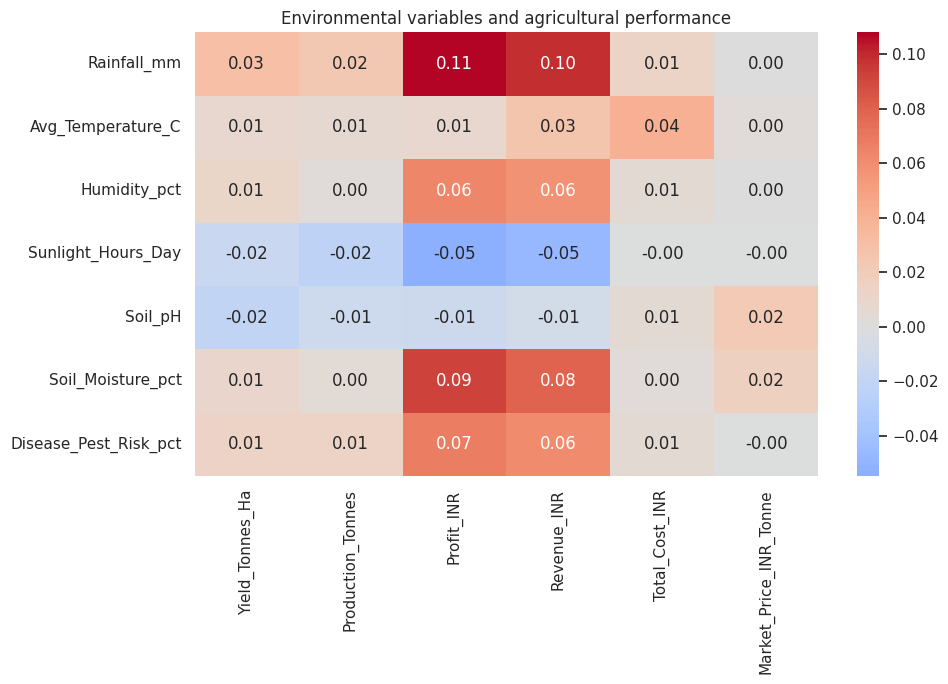

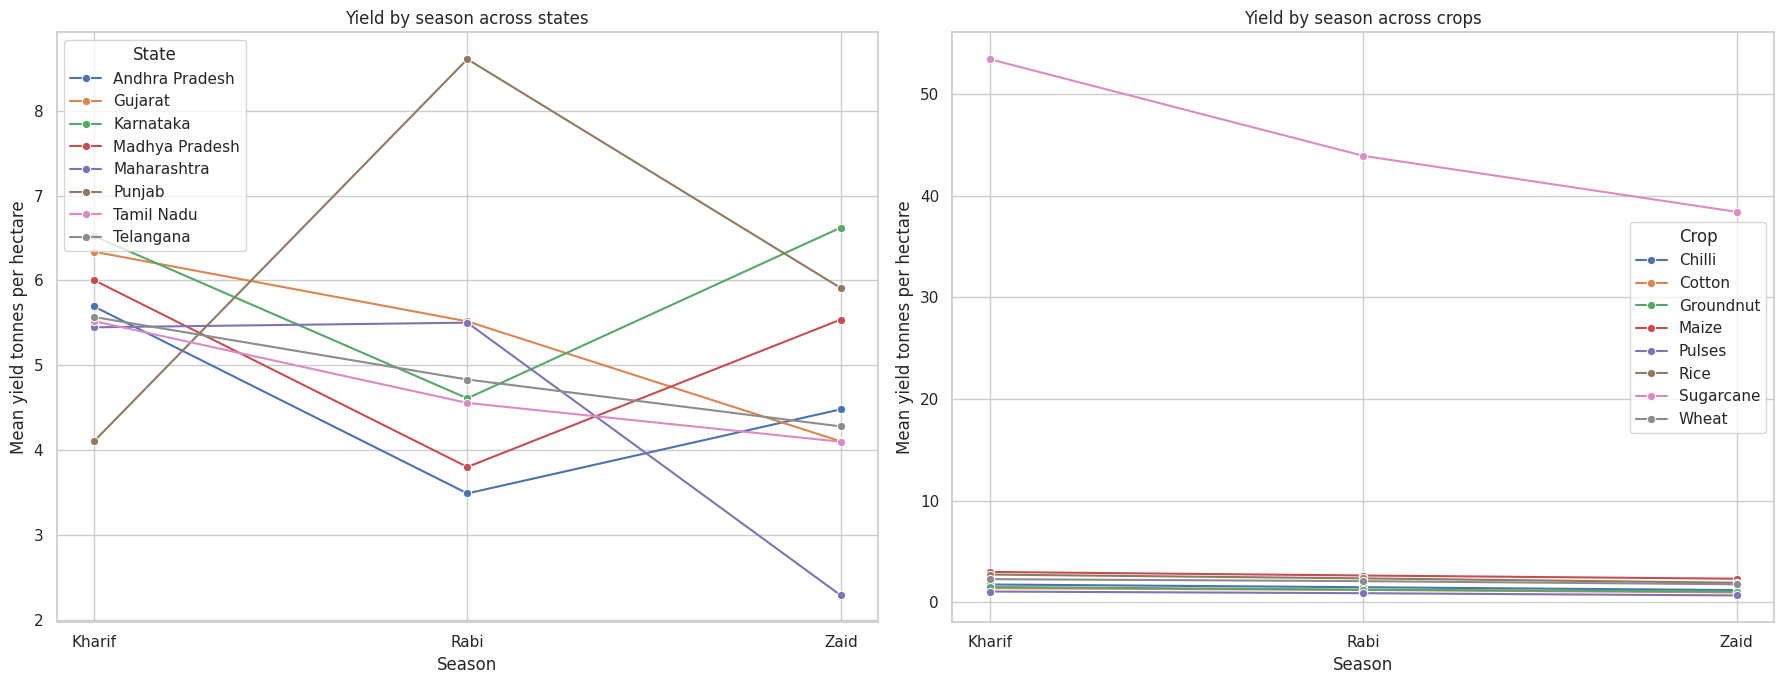


INTERPRETATION
1. Yield is highest in Kharif and lowest in Zaid.
2. Profit is highest in Kharif and lowest in Zaid.
3. Zaid uses the most water on average, while Zaid has the lowest water efficiency.
4. Rainfall, temperature, humidity, sunlight, soil pH, and soil moisture should be interpreted using the correlation table. Near-zero correlations suggest weak direct linear relationships.
5. The regional and crop-level seasonal ranges show whether the overall seasonal pattern is consistent or driven by particular states or crops.
6. The unusual-pattern tables identify farms or crop-season groups whose yield is substantially different from their crop-specific norm.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import kruskal

# Load data
file_path = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path, encoding="ascii")

# Keep a consistent seasonal order
season_order = ["Kharif", "Rabi", "Zaid"]
season_order = [season for season in season_order if season in df["Season"].unique()]

# Main variable groups
performance_cols = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Revenue_INR",
    "Total_Cost_INR",
    "Market_Price_INR_Tonne"
]

resource_cols = [
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha"
]

environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Disease_Pest_Risk_pct"
]

# ---------------------------------------------------------
# 1. Overall seasonal comparison
# ---------------------------------------------------------

season_summary = (
    df.groupby("Season", observed=True)
      [performance_cols + resource_cols + environment_cols]
      .agg(["count", "mean", "median"])
      .reindex(season_order)
)

season_means = (
    df.groupby("Season", observed=True)
      [performance_cols + resource_cols + environment_cols]
      .mean()
      .reindex(season_order)
)

print("\nSEASONAL SAMPLE COUNTS")
print(df["Season"].value_counts().reindex(season_order))

print("\nSEASONAL MEANS")
print(season_means.round(2))

# ---------------------------------------------------------
# 2. Major seasonal patterns
# ---------------------------------------------------------

print("\nMAJOR SEASONAL PATTERNS")

for metric in [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]:
    highest_season = season_means[metric].idxmax()
    lowest_season = season_means[metric].idxmin()

    print(
        f"{metric} - highest in {highest_season} "
        f"and lowest in {lowest_season}"
    )

# ---------------------------------------------------------
# 3. Characteristics that change between seasons
# ---------------------------------------------------------

characteristic_change = season_means.loc[
    :,
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_Moisture_pct",
        # "Seed_Quality_Score", # This column is not present in season_means
        "Fertilizer_kg_ha",
        "Pesticide_Litre_ha",
        "Disease_Pest_Risk_pct"
    ]
].copy()

characteristic_change["Seasonal_Range"] = (
    characteristic_change.max(axis=0)
    - characteristic_change.min(axis=0)
)

characteristic_change = characteristic_change.sort_values(
    "Seasonal_Range",
    ascending=False
)

print("\nCHARACTERISTICS WITH THE LARGEST SEASONAL CHANGES")
print(characteristic_change.round(2))

# ---------------------------------------------------------
# 4. Resource usage comparison
# ---------------------------------------------------------

resource_comparison = season_means[resource_cols].copy()

print("\nRESOURCE USAGE BY SEASON")
print(resource_comparison.round(2))

# ---------------------------------------------------------
# 5. Environmental relationships with performance
# ---------------------------------------------------------

environment_performance_corr = (
    df[environment_cols + performance_cols]
      .corr()
      .loc[environment_cols, performance_cols]
)

print("\nENVIRONMENTAL CORRELATIONS WITH PERFORMANCE")
print(environment_performance_corr.round(3))

# Seasonal environmental correlations
seasonal_corr_rows = []

for current_season in tqdm(
    season_order,
    desc="Calculating seasonal environmental correlations"
):
    current_df = df[df["Season"] == current_season]

    current_corr = (
        current_df[environment_cols + ["Yield_Tonnes_Ha", "Profit_INR"]]
        .corr()
        .loc[environment_cols, ["Yield_Tonnes_Ha", "Profit_INR"]]
        .reset_index()
        .rename(columns={"index": "Environment_Variable"})
    )

    current_corr.insert(0, "Season", current_season)
    seasonal_corr_rows.append(current_corr)

seasonal_environment_corr = pd.concat(
    seasonal_corr_rows,
    ignore_index=True
)

print("\nSEASON-SPECIFIC ENVIRONMENTAL CORRELATIONS")
print(seasonal_environment_corr.round(3))

# ---------------------------------------------------------
# 6. Economic outcomes
# ---------------------------------------------------------

economic_summary = season_means[
    [
        "Market_Price_INR_Tonne",
        "Total_Cost_INR",
        "Revenue_INR",
        "Profit_INR"
    ]
].copy()

economic_summary["Profit_Margin_pct"] = (
    economic_summary["Profit_INR"]
    / economic_summary["Revenue_INR"]
    * 100
)

print("\nECONOMIC OUTCOMES BY SEASON")
print(economic_summary.round(2))

# Percentage of farms with positive profit
positive_profit_rate = (
    df.assign(Positive_Profit=df["Profit_INR"] > 0)
      .groupby("Season", observed=True)["Positive_Profit"]
      .mean()
      .reindex(season_order)
      .mul(100)
)

print("\nPERCENTAGE OF FARMS WITH POSITIVE PROFIT")
print(positive_profit_rate.round(2))

# ---------------------------------------------------------
# 7. Statistical tests for seasonal differences
# ---------------------------------------------------------

test_rows = []

for metric in tqdm(
    [
        "Yield_Tonnes_Ha",
        "Profit_INR",
        "Water_Used_m3",
        "Water_Efficiency_t_per_1000m3",
        "Disease_Pest_Risk_pct"
    ],
    desc="Running seasonal statistical tests"
):
    samples = [
        df.loc[df["Season"] == current_season, metric].dropna()
        for current_season in season_order
    ]

    test_statistic, p_value = kruskal(*samples)

    test_rows.append(
        {
            "Metric": metric,
            "Kruskal_Wallis_H": test_statistic,
            "p_value": p_value,
            "Significant_at_5pct": p_value < 0.05
        }
    )

seasonal_tests = pd.DataFrame(test_rows)

print("\nSTATISTICAL TESTS FOR DIFFERENCES BETWEEN SEASONS")
print(seasonal_tests.round(5))

# ---------------------------------------------------------
# 8. Consistency across regions and crop categories
# ---------------------------------------------------------

state_season_means = (
    df.groupby(["State", "Season"], observed=True)
      [performance_cols + resource_cols]
      .mean()
      .reset_index()
)

crop_season_means = (
    df.groupby(["Crop", "Season"], observed=True)
      [performance_cols + resource_cols]
      .mean()
      .reset_index()
)

state_yield_pivot = state_season_means.pivot(
    index="State",
    columns="Season",
    values="Yield_Tonnes_Ha"
)

crop_yield_pivot = crop_season_means.pivot(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha"
)

state_yield_range = (
    state_yield_pivot.max(axis=1)
    - state_yield_pivot.min(axis=1)
).dropna().sort_values(ascending=False)

crop_yield_range = (
    crop_yield_pivot.max(axis=1)
    - crop_yield_pivot.min(axis=1)
).dropna().sort_values(ascending=False)

print("\nSTATES WITH THE LARGEST SEASONAL YIELD DIFFERENCES")
print(state_yield_range.head(10).round(2))

print("\nCROPS WITH THE LARGEST SEASONAL YIELD DIFFERENCES")
print(crop_yield_range.head(10).round(2))

# ---------------------------------------------------------
# 9. Unusual seasonal patterns
# ---------------------------------------------------------

# Standardize yield within each crop so different crop scales are comparable
crop_yield_mean = df.groupby("Crop", observed=True)["Yield_Tonnes_Ha"].transform("mean")
crop_yield_std = (
    df.groupby("Crop", observed=True)["Yield_Tonnes_Ha"]
      .transform("std")
      .replace(0, np.nan)
)

df["Crop_Relative_Yield_Z"] = (
    df["Yield_Tonnes_Ha"] - crop_yield_mean
) / crop_yield_std

unusual_patterns = (
    df.loc[
        df["Crop_Relative_Yield_Z"].abs() >= 2,
        [
            "Farm_ID",
            "State",
            "District",
            "Crop",
            "Season",
            "Yield_Tonnes_Ha",
            "Profit_INR",
            "Crop_Relative_Yield_Z"
        ]
    ]
    .sort_values(
        "Crop_Relative_Yield_Z",
        key=lambda column: column.abs(),
        ascending=False
    )
)

print("\nUNUSUAL CROP-RELATIVE YIELD OBSERVATIONS")
print(unusual_patterns.head(15).round(2))

# Identify unusual seasonal averages by crop
crop_season_yield = (
    df.groupby(["Crop", "Season"], observed=True)["Yield_Tonnes_Ha"]
      .mean()
      .reset_index()
)

crop_season_yield["Crop_Season_Z"] = (
    crop_season_yield.groupby("Crop", observed=True)["Yield_Tonnes_Ha"]
    .transform(
        lambda values: (
            values - values.mean()
        ) / values.std()
    )
)

print("\nUNUSUAL CROP-SEASON AVERAGES")
print(
    crop_season_yield.loc[
        crop_season_yield["Crop_Season_Z"].abs() >= 1.5
    ]
    .sort_values("Crop_Season_Z", key=lambda column: column.abs(), ascending=False)
    .head(20)
    .round(2)
)

# ---------------------------------------------------------
# 10. Visualizations
# ---------------------------------------------------------

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

boxplot_metrics = [
    ("Yield_Tonnes_Ha", "Yield by season"),
    ("Profit_INR", "Profit by season"),
    ("Water_Used_m3", "Water used by season"),
    ("Water_Efficiency_t_per_1000m3", "Water efficiency by season"),
    ("Disease_Pest_Risk_pct", "Disease and pest risk"),
    ("Revenue_INR", "Revenue by season")
]

for axis, (metric, title) in tqdm(
    zip(axes.ravel(), boxplot_metrics),
    total=len(boxplot_metrics),
    desc="Creating seasonal boxplots"
):
    sns.boxplot(
        data=df,
        x="Season",
        y=metric,
        order=season_order,
        ax=axis,
        color="#8ecae6"
    )
    axis.set_title(title)
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("seasonal_boxplots.png") # Save the combined box plots
plt.show()

# Environmental correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    environment_performance_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Environmental variables and agricultural performance")
plt.tight_layout()
plt.savefig("environmental_correlation_heatmap.png") # Save the heatmap
plt.show()

# Regional consistency
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.lineplot(
    data=state_season_means,
    x="Season",
    y="Yield_Tonnes_Ha",
    hue="State",
    marker="o",
    sort=False,
    ax=axes[0]
)
axes[0].set_title("Yield by season across states")
axes[0].set_ylabel("Mean yield tonnes per hectare")

sns.lineplot(
    data=crop_season_means,
    x="Season",
    y="Yield_Tonnes_Ha",
    hue="Crop",
    marker="o",
    sort=False,
    ax=axes[1]
)
axes[1].set_title("Yield by season across crops")
axes[1].set_ylabel("Mean yield tonnes per hectare")

plt.tight_layout()
plt.savefig("regional_and_crop_yield_consistency.png") # Save the line plots
plt.show()

# Clean helper column
df.drop(columns=["Crop_Relative_Yield_Z"], inplace=True)

# ---------------------------------------------------------
# 11. Automatically generated conclusions
# ---------------------------------------------------------

best_yield_season = season_means["Yield_Tonnes_Ha"].idxmax()
worst_yield_season = season_means["Yield_Tonnes_Ha"].idxmin()
best_profit_season = season_means["Profit_INR"].idxmax()
worst_profit_season = season_means["Profit_INR"].idxmin()
highest_water_season = season_means["Water_Used_m3"].idxmax()
lowest_efficiency_season = season_means[
    "Water_Efficiency_t_per_1000m3"
].idxmin()

print("\nINTERPRETATION")

print(
    f"1. Yield is highest in {best_yield_season} and lowest in "
    f"{worst_yield_season}."
)

print(
    f"2. Profit is highest in {best_profit_season} and lowest in "
    f"{worst_profit_season}."
)

print(
    f"3. {highest_water_season} uses the most water on average, while "
    f"{lowest_efficiency_season} has the lowest water efficiency."
)

print(
    "4. Rainfall, temperature, humidity, sunlight, soil pH, and soil "
    "moisture should be interpreted using the correlation table. "
    "Near-zero correlations suggest weak direct linear relationships."
)

print(
    "5. The regional and crop-level seasonal ranges show whether the "
    "overall seasonal pattern is consistent or driven by particular "
    "states or crops."
)

print(
    "6. The unusual-pattern tables identify farms or crop-season groups "
    "whose yield is substantially different from their crop-specific norm."
)
